# Advanced EDA & Feature Engineering on Housing Dataset

## Project Objective
The objective of this project is to transform raw housing data into a clean and machine-learning-ready dataset through Exploratory Data Analysis (EDA), data preprocessing, outlier treatment, and feature engineering.

### Key Tasks Performed
- Data Loading and Exploration
- Missing Value Analysis
- Outlier Detection and Treatment
- Feature Engineering
- Correlation Analysis
- Data Cleaning
- Exporting Processed Dataset

### Tools & Libraries Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer

Matplotlib is building the font cache; this may take a moment.


## 2. Load Dataset

In [ ]:
df = pd.read_csv(r"C:\Users\Kavya\OneDrive\Desktop\Project_1_EDA_Feature_Engineering\data\Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 3. Dataset Overview

In [ ]:
df.shape

(545, 13)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 4. Missing Value Analysis

In [ ]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].mean(), inplace=True)

C:\Users\Kavya\AppData\Local\Temp\ipykernel_424\2555467876.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mean(), inplace=True)


In [ ]:
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\Kavya\AppData\Local\Temp\ipykernel_424\3154000584.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Kavya\AppData\Local\Temp\ipykernel_424\3154000584.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using

In [ ]:
imputer = KNNImputer(n_neighbors=5)

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

### Missing Value Visualization

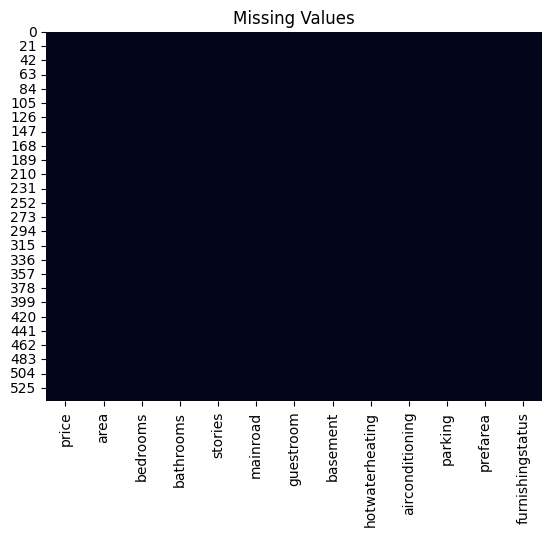

In [ ]:
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")
plt.show()

### Boxplot Analysis

<Figure size 1000x100 with 0 Axes>

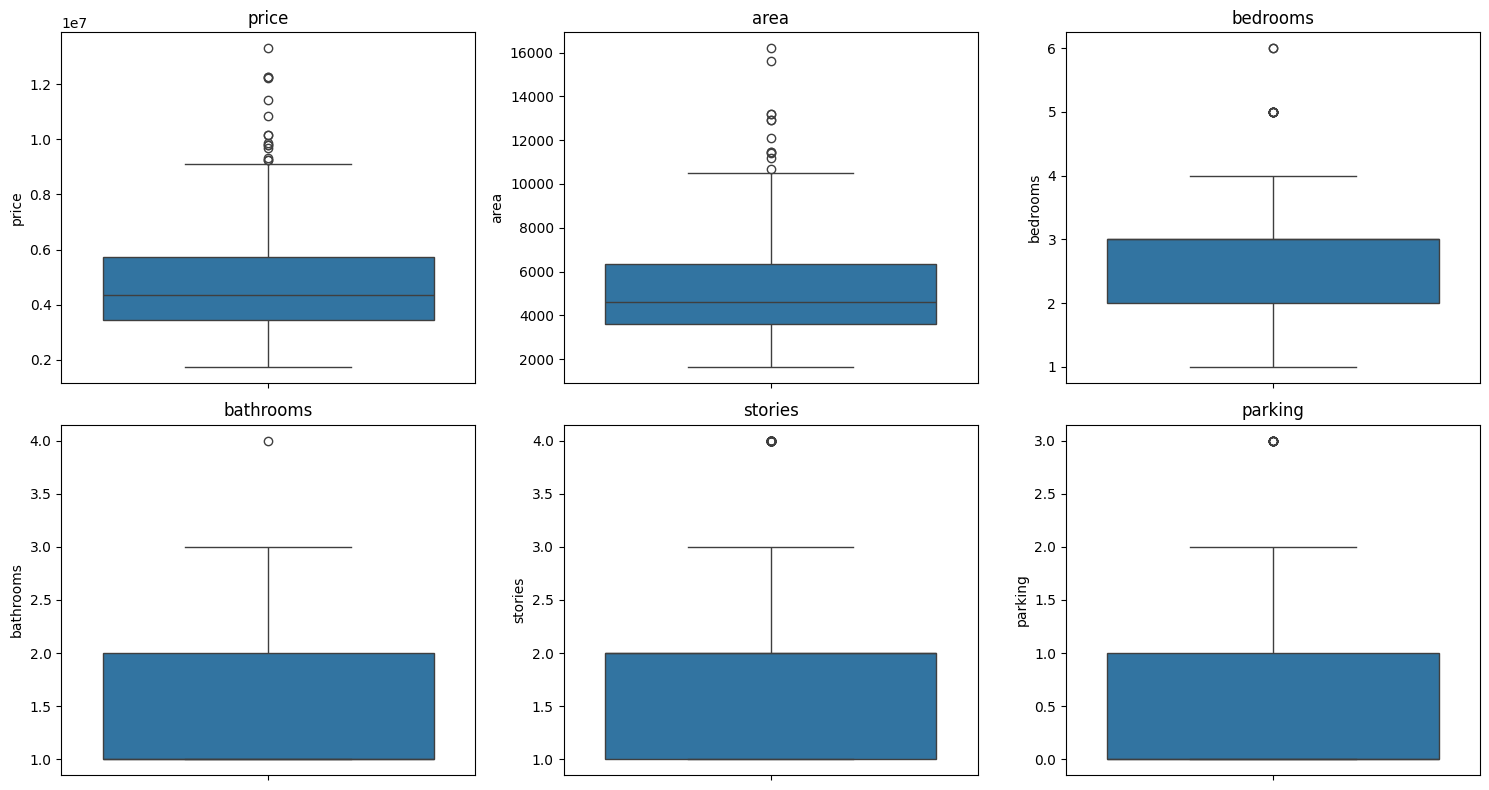

In [ ]:
import math
plt.figure(figsize=(10,1))
n = len(numeric_cols)
cols_per_row = 3  
rows = math.ceil(n / cols_per_row)

fig, axes = plt.subplots(nrows=rows, ncols=cols_per_row, figsize=(5*cols_per_row, 4*rows))
axes = axes.flatten()  
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

## 5. Outlier Detection

In [ ]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

### Correlation Analysis

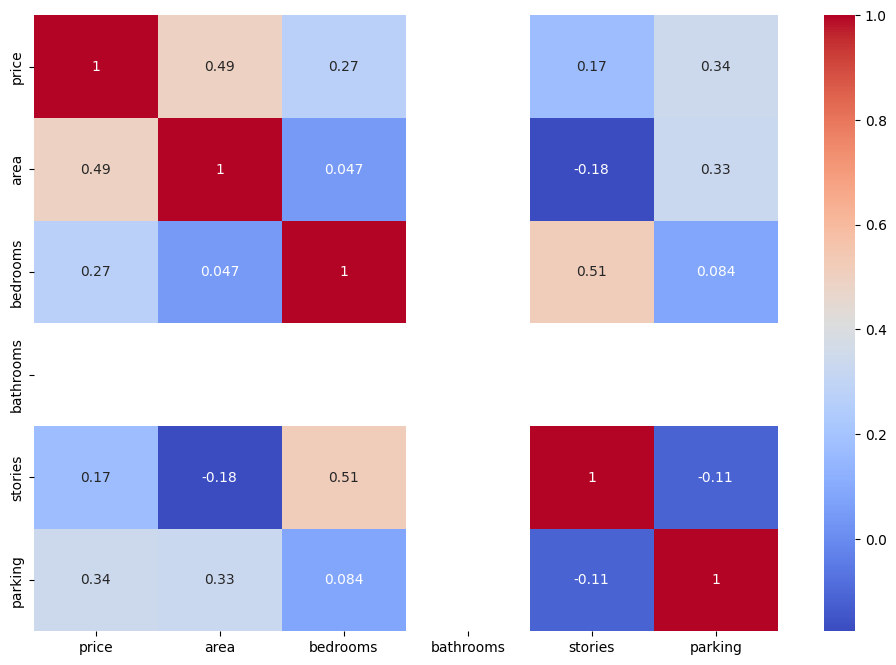

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## 6. Feature Engineering

In [ ]:
df["total_rooms"] = (
    df["bedrooms"] +
    df["bathrooms"]
)

In [ ]:
df["price_per_sqft"] = (
    df["price"] /
    df["area"]
)

In [ ]:
df["house_score"] = (
    df["bedrooms"] * 2 +
    df["bathrooms"] * 3 +
    df["parking"]
)

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms,price_per_sqft,house_score
15,9100000.0,6000.0,4.0,1.0,2.0,yes,no,yes,no,no,2.0,no,semi-furnished,5.0,1516.666667,13.0
20,8750000.0,4320.0,3.0,1.0,2.0,yes,no,yes,yes,no,2.0,no,semi-furnished,4.0,2025.462963,11.0
22,8645000.0,8050.0,3.0,1.0,1.0,yes,yes,yes,no,yes,1.0,no,furnished,4.0,1073.913043,10.0
27,8400000.0,8875.0,3.0,1.0,1.0,yes,no,no,no,no,1.0,no,semi-furnished,4.0,946.478873,10.0
40,7875000.0,6550.0,3.0,1.0,2.0,yes,no,yes,no,yes,0.0,yes,furnished,4.0,1202.290076,9.0


### Feature Distribution Analysis

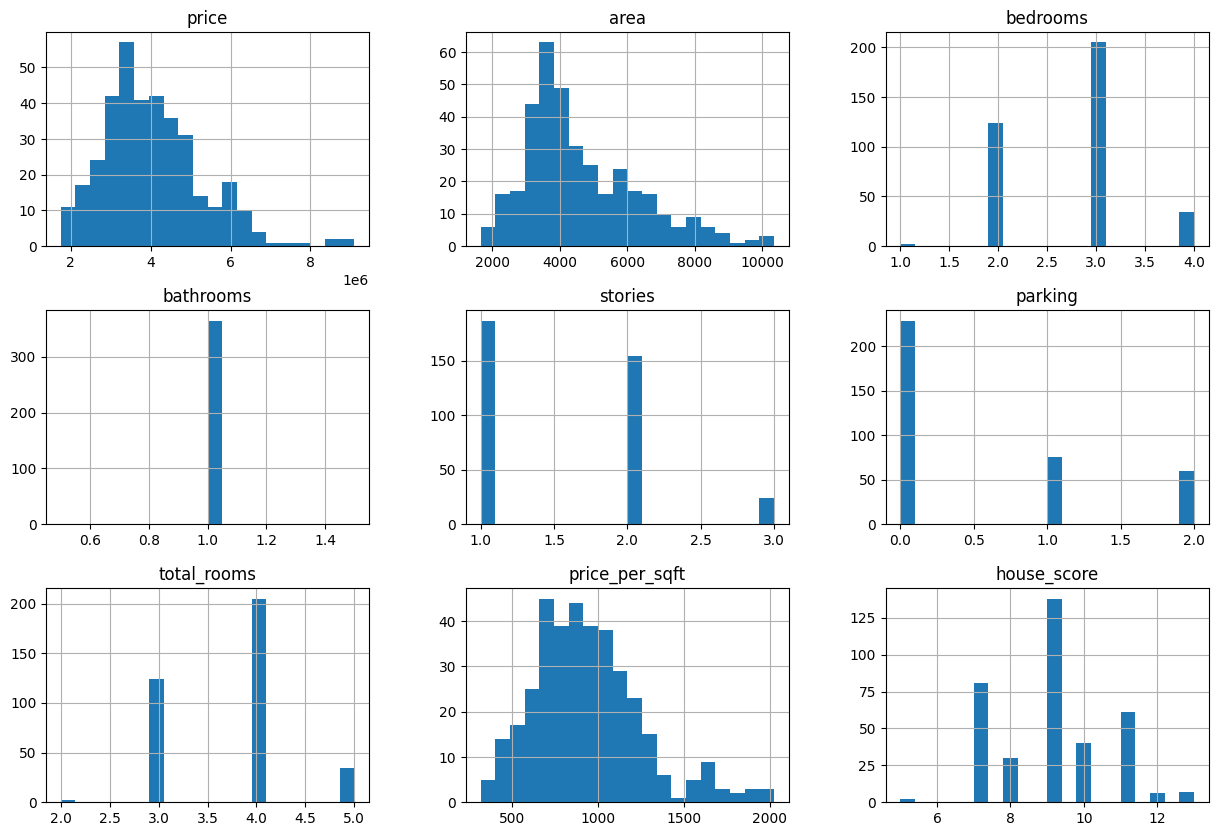

In [ ]:
df.hist(
    figsize=(15,10),
    bins=20
)

plt.show()

## 7. Export Cleaned Dataset

After completing preprocessing and feature engineering, the cleaned dataset is exported and saved for future machine learning tasks.

In [ ]:
df.to_csv(
    "cleaned_data.csv",
    index=False
)

In [ ]:

import pandas as pd
df = pd.read_csv(r"C:\Users\Kavya\OneDrive\Desktop\Project_1_EDA_Feature_Engineering\data\Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Conclusion

This project successfully performed Advanced Exploratory Data Analysis and Feature Engineering on the Housing Dataset.

### Accomplishments

- Loaded and explored the dataset
- Performed statistical analysis
- Checked and handled missing values
- Identified and treated outliers
- Created three new engineered features
- Analyzed feature relationships using correlation analysis
- Exported a clean dataset ready for machine learning

The resulting dataset is now suitable for predictive modeling and serves as a strong foundation for future machine learning applications.